***
# <font color=green size=10>**DS-03 - ANÁLISES BÁSICAS DE DADOS PARA ÁREA DA SAÚDE I - AULA 01**</font>
***

### **Informações importantes**

**CART** é o algoritmo mais clássico para a geração de árvores de decisão capazes de classificar fenômenos. Em geral, para construirmos uma árvore, precisamos descobrir de que modos podemos "separar" os nossos dados de modo a reduzir o grau de impureza.

Dizer isso significa que precisamos descobrir como separar os dados de modo que possamos chegar a uma classificação perfeita (pura). Para chegar ao melhor resultado possível nesse sentido é que existe o algoritmo de geração da árvore.

**No geral, o algoritmo faz o seguinte:**
1. **Qual é o nó raiz da árvore?** Temos que identificar qual será o atributo que fará a melhor divisão da árvore, reduzindo ao máximo a impureza.
2. **Precisamos reduzir ainda mais a impureza?** Se sim, podemos adotar a mesma estratégia do primeiro passo. Saberemos que não é mais necessário reduzir a impureza quando chegarmos a uma folha pura ou quando, por um critério que definirmos, como tamanho máximo da árvore, não pudermos mais seguir reduzindo a impureza de um ou mais nós.
3. **Índice de impureza de Gini para determinação do grau de impureza:**

$$
Gini = 1 - \sum_{i=1}^{n} p_i^{2}
$$

**Atenção:** temos casos em que não queremos classificar um fenômeno de modo binário, mas prever um valor contínuo ou uma probabilidade de 0 a 100%. Para tanto, temos as árvores de regressão.

**A ideia geral do algoritmo não é tão diferente, pois queremos encontrar um nó que divida melhor os dados:**
1. Um nó, de acordo com um critério categórico ou contínuo, separará um conjunto de valores à esquerda e à direita. Calcula-se, então, uma média aritmética desses valores da esquerda e da direita.
2. Ao comparar as várias possibilidades de nós, queremos aquele cuja somatória das diferenças entre dados individuais e as médias que calculamos, seja a menor possível.
3. **Soma dos Quadrados dos Resíduos (RSS):**

$$
RSS = \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^{2}
$$

## <font color=green size=6>**ÁRVORE DE DECISÃO - CLASSIFICAÇÃO**</font>

##### **01. Exemplo simples de classificação - Importação de bibliotecas.**

In [ ]:
# Recurso para trabalharmos com "tabelas com dados" / Dataframes
import pandas as pd

# Recurso para divisão dos dados em treino e teste
from sklearn.model_selection import train_test_split

# Recurso para criação de árvore de decisão capaz de classificar dados
from sklearn.tree import DecisionTreeClassifier

# Recursos para exibição da árvore de decisão
import matplotlib.pyplot as pyplot
from sklearn.tree import plot_tree

# Recursos para cálculo e exibição da matriz de confusão
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

##### **02. Exemplo simples de classificação - Criação do dataframe.**

In [ ]:
# Criação do conjunto de dados
dados = {
    'Brasileiro': [1, 0, 1, 1, 0],
    'VacinadoCovid': [1, 0, 1, 0, 0],
    'Idade': [12, 33, 18, 22, 18],
    'Fraude': [0, 1, 0, 1, 0]
}

In [ ]:
# Criação do dataframe a partir do conjunto de dados
fraudeCartaoVacina = pd.DataFrame(dados)
fraudeCartaoVacina

,Brasileiro,VacinadoCovid,Idade,Fraude
0,1,1,12,0
1,0,0,33,1
2,1,1,18,0
3,1,0,22,1
4,0,0,18,0


##### **03. Exemplo simples de classificação - Separação dos dados de treino e de teste a partir do dataframe criado.**

In [ ]:
# Criação do dataframe com os atributos usados para a classificação
features = fraudeCartaoVacina.drop('Fraude', axis = 1)
features

,Brasileiro,VacinadoCovid,Idade
0,1,1,12
1,0,0,33
2,1,1,18
3,1,0,22
4,0,0,18


In [ ]:
# Criação da series com as categorias de classificação
label = fraudeCartaoVacina['Fraude']
label

0    0
1    1
2    0
3    1
4    0
Name: Fraude, dtype: int64

In [ ]:
# Código para divisão da base de dados em treino e teste
# Normalmente reservamos de 20% a 30% dos dados para teste
features_train, features_test, label_train, label_test = train_test_split(
    features, label, test_size = 0.4, random_state = 1
)

In [ ]:
features_train

,Brasileiro,VacinadoCovid,Idade
4,0,0,18
0,1,1,12
3,1,0,22


In [ ]:
features_test

,Brasileiro,VacinadoCovid,Idade
2,1,1,18
1,0,0,33


In [ ]:
label_train

4    0
0    0
3    1
Name: Fraude, dtype: int64

In [ ]:
label_test

2    0
1    1
Name: Fraude, dtype: int64

##### **04. Exemplo simples de classificação - Criação da árvore de decisão.**

In [ ]:
# 'Tree' é criado como um elemento do tipo Árvore, tendo todas as suas
# propriedades e capacidades
tree = DecisionTreeClassifier()

# O método fit da Árvore realiza o treinamento e os resultados
# ficaram guarados em um novo elemento do tipo Árvore, que optei por criar.
# Trata-se do 'tree_trained'.
tree_trained = tree.fit(features_train, label_train)

##### **05. Exemplo simples de classificação - Exibição da árvore.**

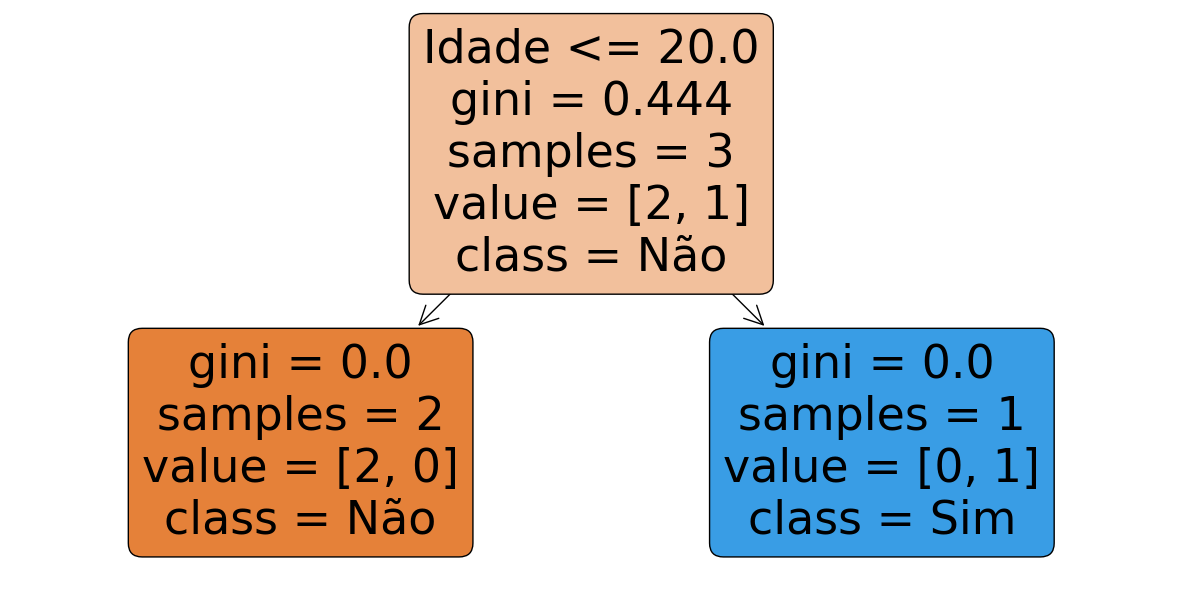

In [ ]:
# Criação do espaço no qual a árvore será criada
pyplot.figure(figsize=(15, 7.5))

# Exibição da árvore sobre o espaço criado
plot_tree(tree_trained,
         filled=True,
         rounded=True,
         class_names=["Não", "Sim"],
         feature_names=features.columns);

##### **06. Exemplo simples de classificação - Cálculo e exibição da matriz de confusão.**

In [ ]:
# Criação das predições com base nos atributos separados para teste
label_pred = tree_trained.predict(features_test)
label_pred

array([0, 1])

In [ ]:
# Cálculo da matriz de confusão comparando os dados reais separados
# para teste e as previsões de classificação geradas pelo modelo
# em função dos atributos de teste que informamos
cm = confusion_matrix(label_test, label_pred)
cm

array([[1, 0],
       [0, 1]])

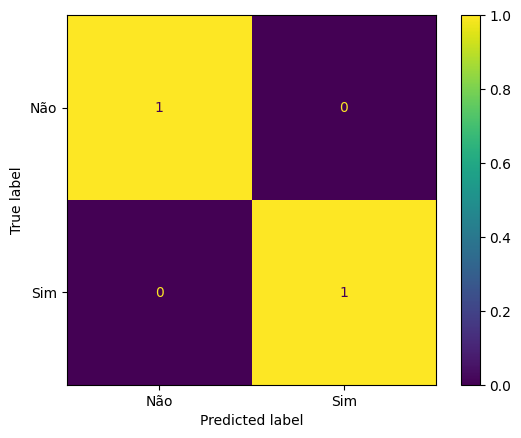

In [ ]:
# Exeibição da matriz de confusão
display_cm = ConfusionMatrixDisplay(confusion_matrix = cm,
                                    display_labels = ["Não", "Sim"])
display_cm.plot(cmap='viridis')

## <font color=green size=6>**TAREFA 01**</font>

**1. Crie dados fictícios relativos a algum assunto do seu interesse, mas que envolva o tema da saúde. Em seguida, repita os passos que já adotamos para criar uma árvore de decisão simples e que tenha por finalidade classificar algum processo ou fenômeno, usando apenas 02 categorias (exe.: sim e não, presente e ausente, bom e ruim etc.).**

***
# <font color=green size=10>**DS-03 - ANÁLISES BÁSICAS DE DADOS PARA ÁREA DA SAÚDE I - AULA 02**</font>
***

In [7]:
# @title Carregamento de módulos e reinicialização do dataframe sobre Dengue

# Carregamento de bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as pyplot
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score
from seaborn import heatmap

# Obtenção da base de dados
dados = pd.read_csv(r'/content/dengue.csv')
df_dengue = pd.DataFrame(dados, columns = ['Year', 'State', 'Population', 'Region', 'Min_Tmp',
                                               'Max_Tmp', 'Change_Tmp', 'Mean_Tmp', 'Percipitation','Cases'])
df_dengue = df_dengue.dropna()

# Criação de novas variáveis
mediana = df_dengue['Cases'].median()
def ident_se_muitos_casos(casos):
  if casos > mediana:
    return 1
  else:
    return 0

df_dengue['SeveralCases'] = df_dengue['Cases'].apply(ident_se_muitos_casos)

def estado_para_cod(estado):
  if estado == 'Distrito Federal':
    return 1
  elif estado == 'Minas Gerais':
    return 2
  elif estado == 'Parana':
    return 3
  else:
    return 0

df_dengue['FromMainStates'] = df_dengue['State'].apply(estado_para_cod)

def div_duas_regioes(regiao):
  if regiao == 'N' or regiao == 'NE' or regiao == 'CO':
    return 1
  else:
    return 2

df_dengue['FromNNECOorSSE'] = df_dengue['Region'].apply(div_duas_regioes)

df_dengue['%CasesInPop'] = (df_dengue['Cases'] / df_dengue['Population'])*100

# Exibição do dataframe
df_dengue.head()

,Year,State,Population,Region,Min_Tmp,Max_Tmp,Change_Tmp,Mean_Tmp,Percipitation,Cases,SeveralCases,FromMainStates,FromNNECOorSSE,%CasesInPop
0,2012,Acre,758786,N,20.48,31.05,10.57,25.74,1851.90,22,0,0,1,0.002899
1,2013,Acre,776463,N,20.40,30.86,10.46,25.61,1909.14,9229,0,0,1,1.188595
2,2014,Acre,790101,N,20.57,31.04,10.47,25.78,2243.00,36795,1,0,1,4.657000
3,2015,Acre,803513,N,20.88,31.62,10.74,26.22,1895.83,14320,1,0,1,1.782174
4,2016,Acre,816687,N,20.66,31.71,11.05,26.16,1874.84,9237,0,0,1,1.131033


##### **01. Separação dos dados em features e target, sendo este último a variável SeveralCases.**

In [8]:
# Remoção do dataframe 'features' as variáveis year, state, region e severalcases
features = df_dengue.drop(['Year', 'State', 'Region', 'Cases', 'SeveralCases'], axis = 1)
features

,Population,Min_Tmp,Max_Tmp,Change_Tmp,Mean_Tmp,Percipitation,FromMainStates,FromNNECOorSSE,%CasesInPop
0,758786,20.48,31.05,10.57,25.74,1851.90,0,1,0.002899
1,776463,20.40,30.86,10.46,25.61,1909.14,0,1,1.188595
2,790101,20.57,31.04,10.47,25.78,2243.00,0,1,4.657000
3,803513,20.88,31.62,10.74,26.22,1895.83,0,1,1.782174
4,816687,20.66,31.71,11.05,26.16,1874.84,0,1,1.131033
...,...,...,...,...,...,...,...,...,...
254,1550194,21.96,33.66,11.70,27.79,1320.86,0,1,0.960009
255,1555229,21.81,33.29,11.48,27.53,1749.54,0,1,0.529568
256,1572866,21.93,33.96,12.03,27.92,1271.12,0,1,1.964630
257,1590248,21.89,33.65,11.76,27.74,1729.92,0,1,0.353718


In [9]:
# Criação do target com a variável SeveralCases
target = df_dengue['SeveralCases']
target

,SeveralCases
0,0
1,0
2,1
3,1
4,0
5,0
6,1
7,1
8,1
9,0


##### **02. Conversão da variável FromMainStates em dicotômica.**

In [10]:
# Criação das variáveis dicotômicas a partir de 'FromMainStates'
# features = pd.get_dummies(features, columns=['FromMainStates'])
features[['FromMainStates_0',
          'FromMainStates_1',
          'FromMainStates_2',
          'FromMainStates_3']] = pd.get_dummies(features,
                                                columns=['FromMainStates'])[['FromMainStates_0',
                                                                                       'FromMainStates_1',
                                                                                       'FromMainStates_2',
                                                                                       'FromMainStates_3']].astype(int)
features

,Population,Min_Tmp,Max_Tmp,Change_Tmp,Mean_Tmp,Percipitation,FromMainStates,FromNNECOorSSE,%CasesInPop,FromMainStates_0,FromMainStates_1,FromMainStates_2,FromMainStates_3
0,758786,20.48,31.05,10.57,25.74,1851.90,0,1,0.002899,1,0,0,0
1,776463,20.40,30.86,10.46,25.61,1909.14,0,1,1.188595,1,0,0,0
2,790101,20.57,31.04,10.47,25.78,2243.00,0,1,4.657000,1,0,0,0
3,803513,20.88,31.62,10.74,26.22,1895.83,0,1,1.782174,1,0,0,0
4,816687,20.66,31.71,11.05,26.16,1874.84,0,1,1.131033,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
254,1550194,21.96,33.66,11.70,27.79,1320.86,0,1,0.960009,1,0,0,0
255,1555229,21.81,33.29,11.48,27.53,1749.54,0,1,0.529568,1,0,0,0
256,1572866,21.93,33.96,12.03,27.92,1271.12,0,1,1.964630,1,0,0,0
257,1590248,21.89,33.65,11.76,27.74,1729.92,0,1,0.353718,1,0,0,0


🎯**Desafio**

Tente aperfeiçoar este código de criação de variáveis dicotômicas.

In [11]:
# Renomeando as variáveis criadas pelo get_dummies
features = features.rename(columns={
    'FromMainStates_0': 'OutrosEstados',
    'FromMainStates_1': 'DF',
    'FromMainStates_2': 'MG',
    'FromMainStates_3': 'PR'
})
features

,Population,Min_Tmp,Max_Tmp,Change_Tmp,Mean_Tmp,Percipitation,FromMainStates,FromNNECOorSSE,%CasesInPop,OutrosEstados,DF,MG,PR
0,758786,20.48,31.05,10.57,25.74,1851.90,0,1,0.002899,1,0,0,0
1,776463,20.40,30.86,10.46,25.61,1909.14,0,1,1.188595,1,0,0,0
2,790101,20.57,31.04,10.47,25.78,2243.00,0,1,4.657000,1,0,0,0
3,803513,20.88,31.62,10.74,26.22,1895.83,0,1,1.782174,1,0,0,0
4,816687,20.66,31.71,11.05,26.16,1874.84,0,1,1.131033,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
254,1550194,21.96,33.66,11.70,27.79,1320.86,0,1,0.960009,1,0,0,0
255,1555229,21.81,33.29,11.48,27.53,1749.54,0,1,0.529568,1,0,0,0
256,1572866,21.93,33.96,12.03,27.92,1271.12,0,1,1.964630,1,0,0,0
257,1590248,21.89,33.65,11.76,27.74,1729.92,0,1,0.353718,1,0,0,0


In [12]:
features = features[['Population',
                     'FromNNECOorSSE',
                     'DF',
                     'MG',
                     'PR',
                     'OutrosEstados',
                     'Min_Tmp',
                     'Max_Tmp',
                     'Change_Tmp',
                     'Mean_Tmp',
                     'Percipitation',
                     '%CasesInPop']]
features

,Population,FromNNECOorSSE,DF,MG,PR,OutrosEstados,Min_Tmp,Max_Tmp,Change_Tmp,Mean_Tmp,Percipitation,%CasesInPop
0,758786,1,0,0,0,1,20.48,31.05,10.57,25.74,1851.90,0.002899
1,776463,1,0,0,0,1,20.40,30.86,10.46,25.61,1909.14,1.188595
2,790101,1,0,0,0,1,20.57,31.04,10.47,25.78,2243.00,4.657000
3,803513,1,0,0,0,1,20.88,31.62,10.74,26.22,1895.83,1.782174
4,816687,1,0,0,0,1,20.66,31.71,11.05,26.16,1874.84,1.131033
...,...,...,...,...,...,...,...,...,...,...,...,...
254,1550194,1,0,0,0,1,21.96,33.66,11.70,27.79,1320.86,0.960009
255,1555229,1,0,0,0,1,21.81,33.29,11.48,27.53,1749.54,0.529568
256,1572866,1,0,0,0,1,21.93,33.96,12.03,27.92,1271.12,1.964630
257,1590248,1,0,0,0,1,21.89,33.65,11.76,27.74,1729.92,0.353718


##### **03. Avaliação das correlações entre as features.**

In [13]:
feat_train, feat_test, targ_train, targ_test = train_test_split(
    features, target, test_size = 0.3, random_state = 1
)

In [14]:
feat_train.shape

(180, 12)

In [15]:
feat_test.shape

(78, 12)

In [16]:
targ_train.shape

(180,)

In [17]:
targ_test.shape

(78,)

##### **04. Divisão dos dados de teste e de treino.**

<Axes: >

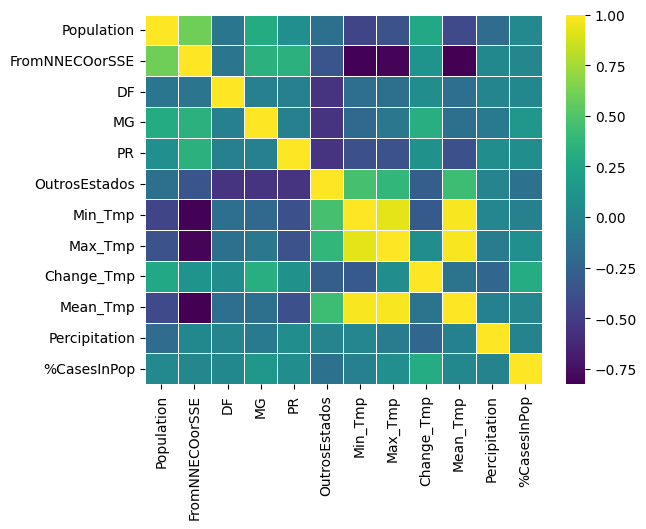

In [19]:
heatmap(features.corr(method='pearson'), cmap='viridis', linewidths=.5)

##### **05. Criação da árvore.**

In [20]:
# Criamos uma instância do elemento árvore
tree = DecisionTreeClassifier(random_state=1)

In [21]:
# Treinamento da árvore
tree_trained = tree.fit(feat_train, targ_train)

##### **06. Exibição da árvore.**

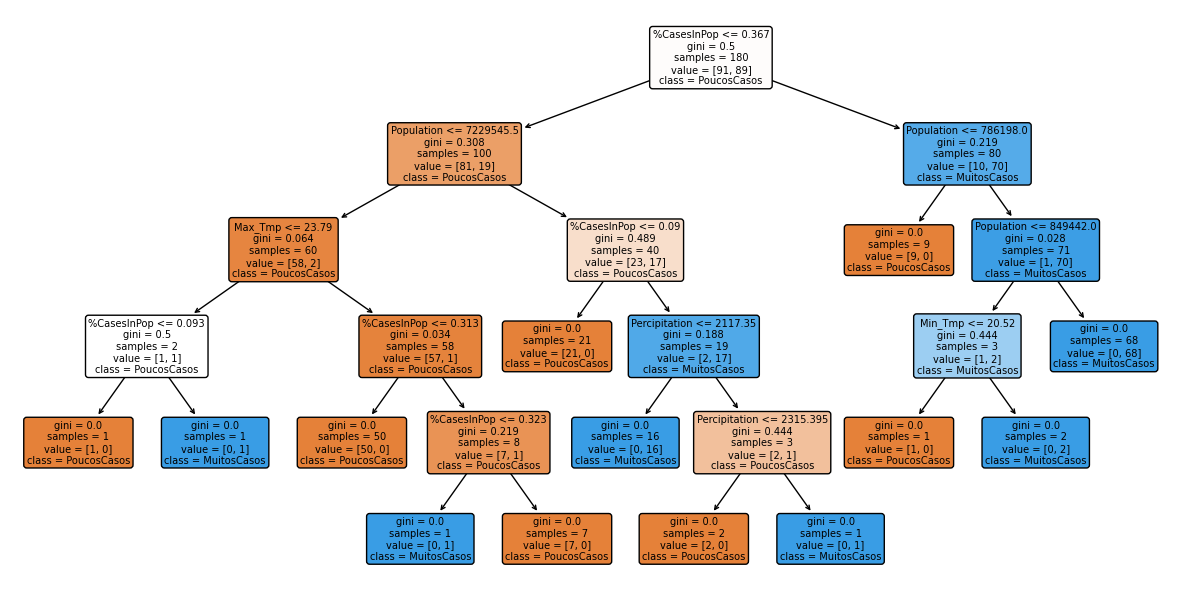

In [22]:
# Criação do espaço no qual a árvore será criada
pyplot.figure(figsize=(15, 7.5))

# Exibição da árvore sobre o espaço criado
plot_tree(tree_trained,
         filled=True,
         rounded=True,
         class_names=["PoucosCasos", "MuitosCasos"],
         feature_names=features.columns);

##### **07. Criação das previsões da árvore.**

In [23]:
# Criação das previsões baseadas nos atributos de teste
targ_predicted = tree_trained.predict(feat_test)
targ_predicted

array([1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1])

##### **08. Exibição da matriz de confusão.**

In [24]:
# Exibição da matriz de confusão em formato simplificado
conf_mtrx = confusion_matrix(targ_test, targ_predicted)
conf_mtrx

array([[34,  4],
       [ 3, 37]])

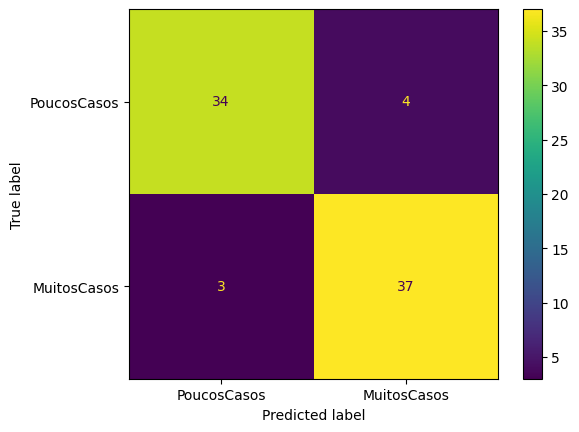

In [25]:
conf_mtrx_view = ConfusionMatrixDisplay(confusion_matrix = conf_mtrx,
                                    display_labels = ["PoucosCasos", "MuitosCasos"])
conf_mtrx_view.plot(cmap='viridis')

##### **09. Cálculo de métricas de qualidade do modelo.**

In [26]:
# Verifica todos os tipos de acertos
print("Acurácia\n", round(accuracy_score(targ_test, targ_predicted)*100, 2), "\n")

# Verifica os acertos de MuitosCasos e busca minimizar Falsos Positivos
print("Precisão\n", round(precision_score(targ_test, targ_predicted)*100, 2), "\n")

# Verifica os acertos de MuitosCasos e busca minimizar Falsos Negativos
print("Recall\n", round(recall_score(targ_test, targ_predicted)*100, 2), "\n")

Acurácia
 91.03 

Precisão
 90.24 

Recall
 92.5 



##### **10. Tentativas de aperfeiçoamento da árvore.**

In [27]:
tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 1,
 'splitter': 'best'}

💡**Bônus**

Para entender melhor cada hiperparâmetro, consulte a [documentação](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).

In [28]:
tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=1)
tree_trained_opt = tree.fit(feat_train, targ_train)
targ_predicted = tree_trained_opt.predict(feat_test)
conf_mtrx = confusion_matrix(targ_test, targ_predicted)
print("Matriz de confusão\n", conf_mtrx, "\n")

# Avalia acertos na identificação de verdadeiros positivos e negativos
print("Acurácia\n", round(accuracy_score(targ_test, targ_predicted)*100, 2), "\n")

# Minimiza falsos positivos
print("Precisão\n", round(precision_score(targ_test, targ_predicted)*100, 2), "\n")

# Minimiza falsos negativos
print("Recall\n", round(recall_score(targ_test, targ_predicted)*100, 2), "\n")

Matriz de confusão
 [[34  4]
 [ 3 37]] 

Acurácia
 91.03 

Precisão
 90.24 

Recall
 92.5 



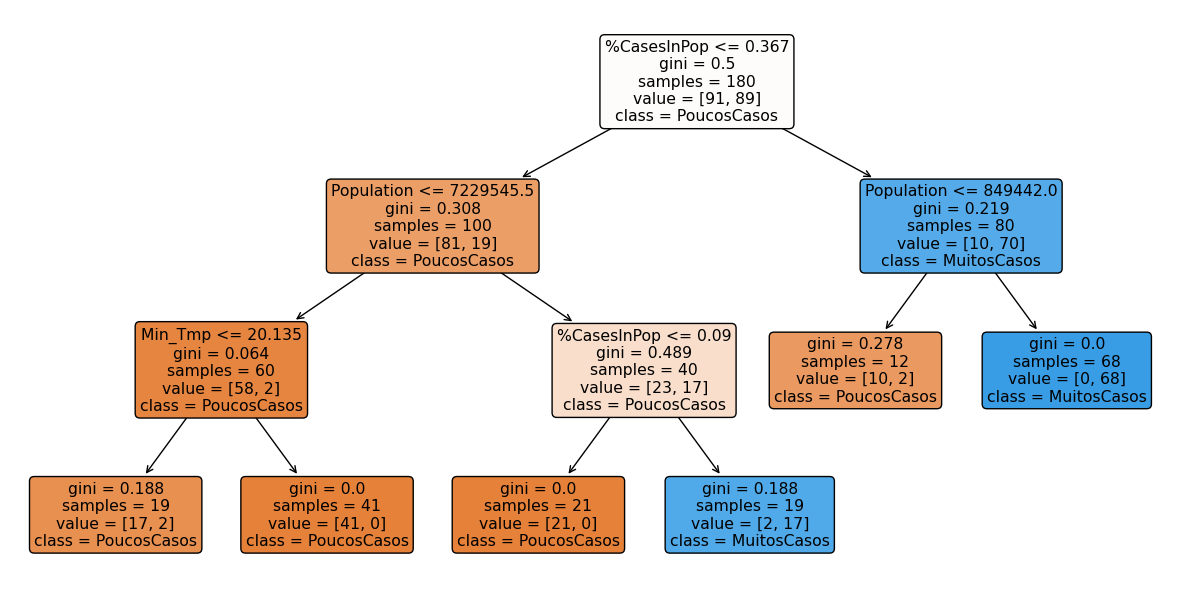

In [29]:
# Criação do espaço no qual a árvore será criada
pyplot.figure(figsize=(15, 7.5))

# Exibição da árvore sobre o espaço criado
plot_tree(tree_trained_opt,
         filled=True,
         rounded=True,
         class_names=["PoucosCasos", "MuitosCasos"],
         feature_names=features.columns);

💡**Bônus**

Vamos identificar e calcular o grau de importância de cada feature para o nosso modelo.

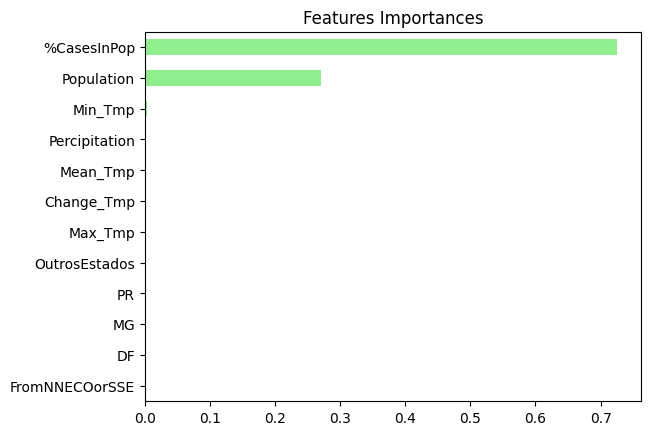

In [30]:
# @title Grau de Importância de cada feature

# Obtenção dos valores de importância
importances = pd.Series(data=tree_trained_opt.feature_importances_, index = feat_train.columns)
importances_sorted = importances.sort_values()

# Apresentação do grau de importância em um gráfico
importances_sorted.plot(kind='barh', color='lightgreen')
pyplot.title('Features Importances')
pyplot.show()

## <font color=green size=6>**TAREFA 02**</font>

**1. Busque aperfeiçoar a árvore de decisão para previsão do quantitativo de casos de dengue, removendo as features 'Population' e '%CasesInPop'. Caso avalie como promissor, você pode remover outras variáveis.**

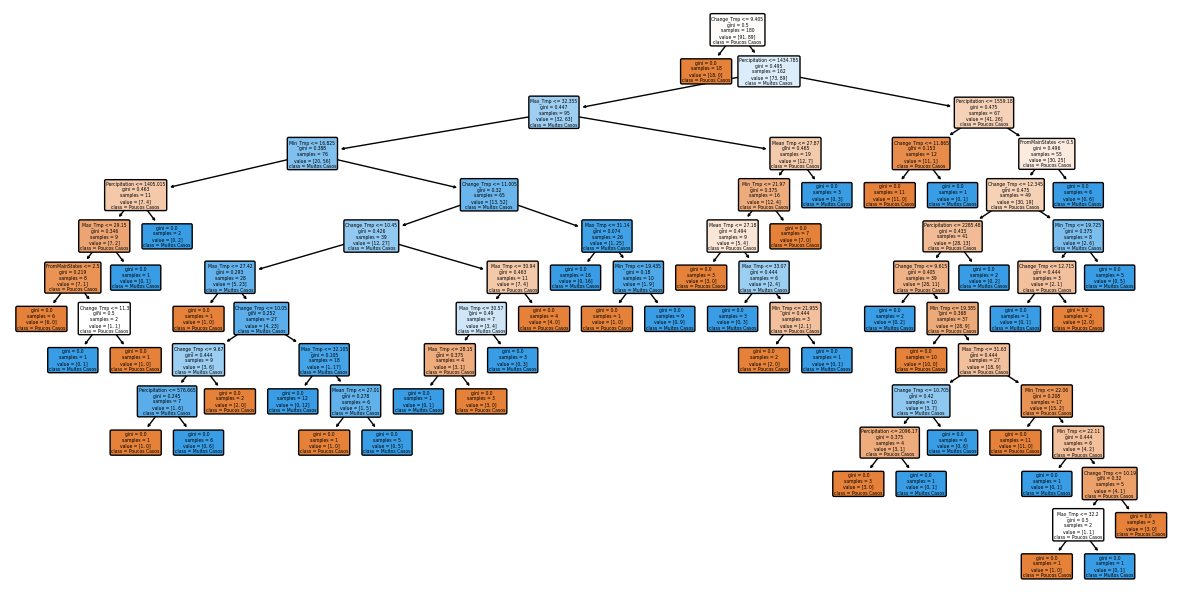

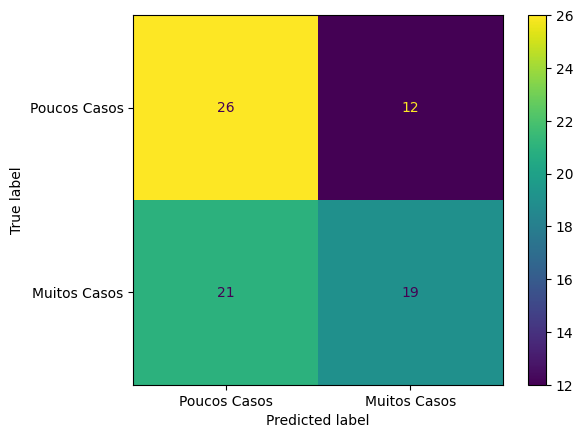

Acurácia: 57.69
Precisão: 61.29
Recall: 47.5


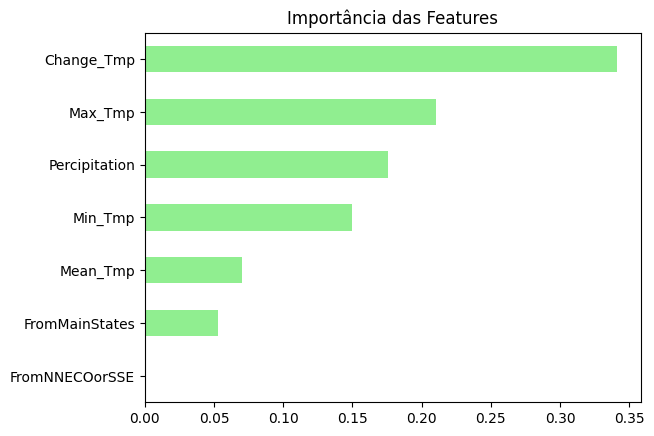

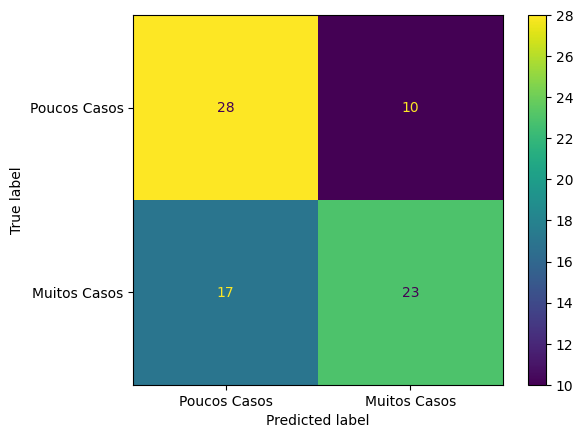

Acurácia (Otimizada): 65.38
Precisão (Otimizada): 69.7
Recall (Otimizada): 57.5


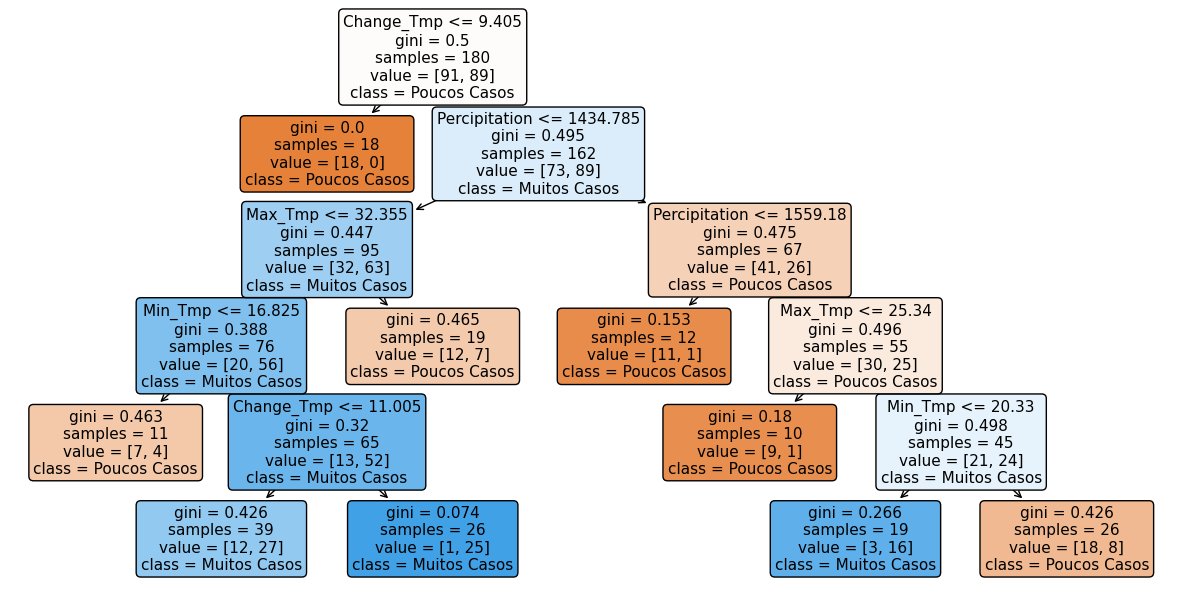

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

# Remoção das variáveis 'Population' e '%CasesInPop' e definição das features
features = df_dengue[['Min_Tmp', 'Max_Tmp', 'Change_Tmp', 'Mean_Tmp', 'Percipitation', 'FromMainStates', 'FromNNECOorSSE']]

# Atualização do target
target = df_dengue['SeveralCases']

# Divisão dos dados de treino e teste
feat_train, feat_test, targ_train, targ_test = train_test_split(features, target, test_size=0.3, random_state=1)

# Criação da árvore
tree = DecisionTreeClassifier(random_state=1)

# Treinamento da árvore
tree_trained = tree.fit(feat_train, targ_train)

# Exibição da árvore treinada
plt.figure(figsize=(15, 7.5))
plot_tree(tree_trained, filled=True, rounded=True, class_names=["Poucos Casos", "Muitos Casos"], feature_names=features.columns)
plt.show()

# Criação das previsões
targ_predicted = tree_trained.predict(feat_test)

# Exibição da matriz de confusão
conf_mtrx = confusion_matrix(targ_test, targ_predicted)
conf_mtrx_view = ConfusionMatrixDisplay(confusion_matrix=conf_mtrx, display_labels=["Poucos Casos", "Muitos Casos"])
conf_mtrx_view.plot(cmap='viridis')
plt.show()

# Cálculo de métricas de avaliação
print("Acurácia:", round(accuracy_score(targ_test, targ_predicted) * 100, 2))
print("Precisão:", round(precision_score(targ_test, targ_predicted) * 100, 2))
print("Recall:", round(recall_score(targ_test, targ_predicted) * 100, 2))

# Exibição da importância das features
importances = pd.Series(tree_trained.feature_importances_, index=features.columns)
importances_sorted = importances.sort_values()

# Gráfico da importância das features
importances_sorted.plot(kind='barh', color='lightgreen')
plt.title('Importância das Features')
plt.show()

# Remoção de features menos importantes (ajuste conforme necessário)
selected_features = importances_sorted[importances_sorted > 0.01].index.tolist()
features = df_dengue[selected_features]

# Nova divisão dos dados de treino e teste com features selecionadas
feat_train, feat_test, targ_train, targ_test = train_test_split(features, target, test_size=0.3, random_state=1)

# Criação e treinamento da árvore otimizada
tree_opt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=1)
tree_trained_opt = tree_opt.fit(feat_train, targ_train)
targ_predicted_opt = tree_trained_opt.predict(feat_test)

# Avaliação do modelo otimizado
conf_mtrx_opt = confusion_matrix(targ_test, targ_predicted_opt)
conf_mtrx_view_opt = ConfusionMatrixDisplay(confusion_matrix=conf_mtrx_opt, display_labels=["Poucos Casos", "Muitos Casos"])
conf_mtrx_view_opt.plot(cmap='viridis')
plt.show()

print("Acurácia (Otimizada):", round(accuracy_score(targ_test, targ_predicted_opt) * 100, 2))
print("Precisão (Otimizada):", round(precision_score(targ_test, targ_predicted_opt) * 100, 2))
print("Recall (Otimizada):", round(recall_score(targ_test, targ_predicted_opt) * 100, 2))

# Exibição da árvore otimizada
plt.figure(figsize=(15, 7.5))
plot_tree(tree_trained_opt, filled=True, rounded=True, class_names=["Poucos Casos", "Muitos Casos"], feature_names=features.columns)
plt.show()
